# Project Provenance and Environment\nThis cell displays the execution fingerprint, model configurations, and data volume at each phase boundary.

In [1]:

import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path("../")

def load_json(path):
    if path.exists():
        with open(path, "r") as f:
            return json.load(f)
    return {}

env = load_json(ROOT / "output/results/environment/evidence/env_fingerprint.json")
p1 = load_json(ROOT / "output/results/phase1/v2/ingestion_manifest_v2.json")
p2 = load_json(ROOT / "output/results/phase2/v3/preprocessing_manifest_v3.json")
p3 = load_json(ROOT / "output/results/phase3/v3/sentiment_manifest_v3.json")
p4 = load_json(ROOT / "data/03_processed/v3/phase4_manifest_v3.json")
p5 = load_json(ROOT / "output/results/phase5/v3/phase5_manifest_v3.json")

print("=== Environment ===")
print(f"Python: {env.get('python_version')}")
print(f"CUDA Available: {env.get('cuda_available')}")
print(f"CUDA Device: {env.get('cuda_device_name')}")
print(f"Torch: {env.get('torch_version')}")

print("\n=== Phase 1 (Ingestion) ===")
print(f"Run ID: {p1.get('run_id')}")
print(f"Raw Tweets (Trump): {p1.get('streams', {}).get('twitter_donald_trump_v2', {}).get('record_count')}")
print(f"Raw Tweets (Biden): {p1.get('streams', {}).get('twitter_joe_biden_v2', {}).get('record_count')}")

print("\n=== Phase 2 (Preprocessing v3) ===")
print(f"Run ID: {p2.get('run_id')}")
print(f"Total Unique Tweets: {p2.get('final_cleaned_record_count')}")

print("\n=== Phase 3 (Sentiment v3) ===")
print(f"Run ID: {p3.get('run_id')}")
print(f"Model: {p3.get('primary_sentiment_model')}")
print(f"Revision SHA: {p3.get('model_revision_sha')}")
print(f"Throughput: {p3.get('throughput_tweets_per_sec', 0):.2f} tweets/sec")

print("\n=== Phase 4 (Aggregation v3) ===")
print(f"Temporal Both Count: {p4.get('temporal_both_row_count')}")
print(f"Spatial Both Count: {p4.get('spatial_both_row_count')}")


=== Environment ===
Python: 3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]
CUDA Available: True
CUDA Device: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Torch: 2.13.0+cu126

=== Phase 1 (Ingestion) ===
Run ID: phase1_v2_verified_window_20260714
Raw Tweets (Trump): 970765
Raw Tweets (Biden): 776777

=== Phase 2 (Preprocessing v3) ===
Run ID: phase2_v3_multivariable_20260801
Total Unique Tweets: 1297753

=== Phase 3 (Sentiment v3) ===
Run ID: phase3_v3_roberta_inference_20260801
Model: cardiffnlp/twitter-roberta-base-sentiment-latest
Revision SHA: 3216a57f2a0d9c45a2e6c20157c20c49fb4bf9c7
Throughput: 599.35 tweets/sec

=== Phase 4 (Aggregation v3) ===
Temporal Both Count: 183935
Spatial Both Count: 183935


## N1: User Activity Filter Analysis
0.46% of *users* held 12.72% of *tweets* — the disproportion is the actual finding. Below is the histogram from the Phase 1 v2 pre-filter full data.

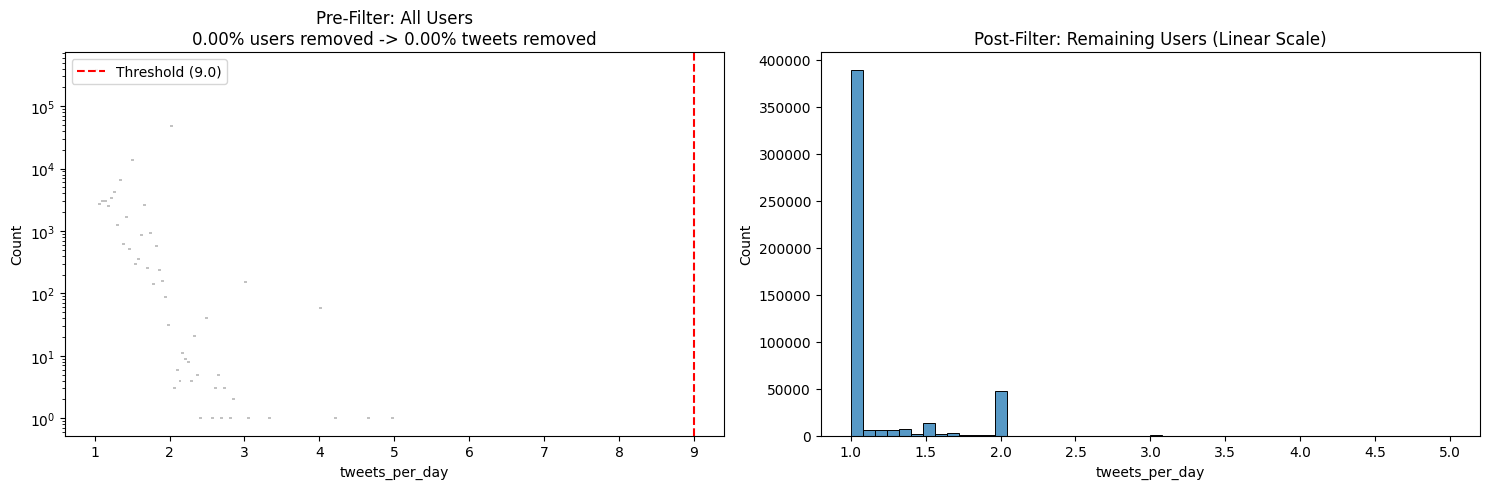

In [2]:

df_t = pd.read_parquet(ROOT / "data/02_interim/phase1_v2/twitter_donald_trump_v2.parquet", columns=["user_id", "date"])
df_b = pd.read_parquet(ROOT / "data/02_interim/phase1_v2/twitter_joe_biden_v2.parquet", columns=["user_id", "date"])
df_p1 = pd.concat([df_t, df_b])

user_stats = df_p1.groupby("user_id").agg(
    n_tweets=("date", "count"),
    active_days=("date", "nunique")
)
user_stats["tweets_per_day"] = user_stats["n_tweets"] / user_stats["active_days"]

threshold = 9.0
high_users = user_stats[user_stats["tweets_per_day"] > threshold]
n_users_total = len(user_stats)
n_users_removed = len(high_users)
pct_users_removed = (n_users_removed / n_users_total) * 100

n_tweets_total = len(df_p1)
n_tweets_removed = high_users["n_tweets"].sum()
pct_tweets_removed = (n_tweets_removed / n_tweets_total) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: Pre-filter Full Distribution (Log scale for visibility)
sns.histplot(user_stats["tweets_per_day"], bins=100, ax=axes[0], log_scale=(False, True))
axes[0].axvline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
axes[0].set_title(f"Pre-Filter: All Users\n{pct_users_removed:.2f}% users removed -> {pct_tweets_removed:.2f}% tweets removed")
axes[0].legend()

# Panel 2: Post-filter
sns.histplot(user_stats[user_stats["tweets_per_day"] <= threshold]["tweets_per_day"], bins=50, ax=axes[1])
axes[1].set_title("Post-Filter: Remaining Users (Linear Scale)")

plt.tight_layout()
plt.show()


## N2: Temporal Volume and the Election Call
The flip in volume on November 7–8 is a genuine event response (the race being called for Biden by AP and major networks), measured in the raw pre-filter parquets, and it is a usable H1 validation case.
Note: Nov 9–15 is absent because the Kaggle source (Version 19) stopped collecting on Nov 8, so the decay of that spike is unobserved.

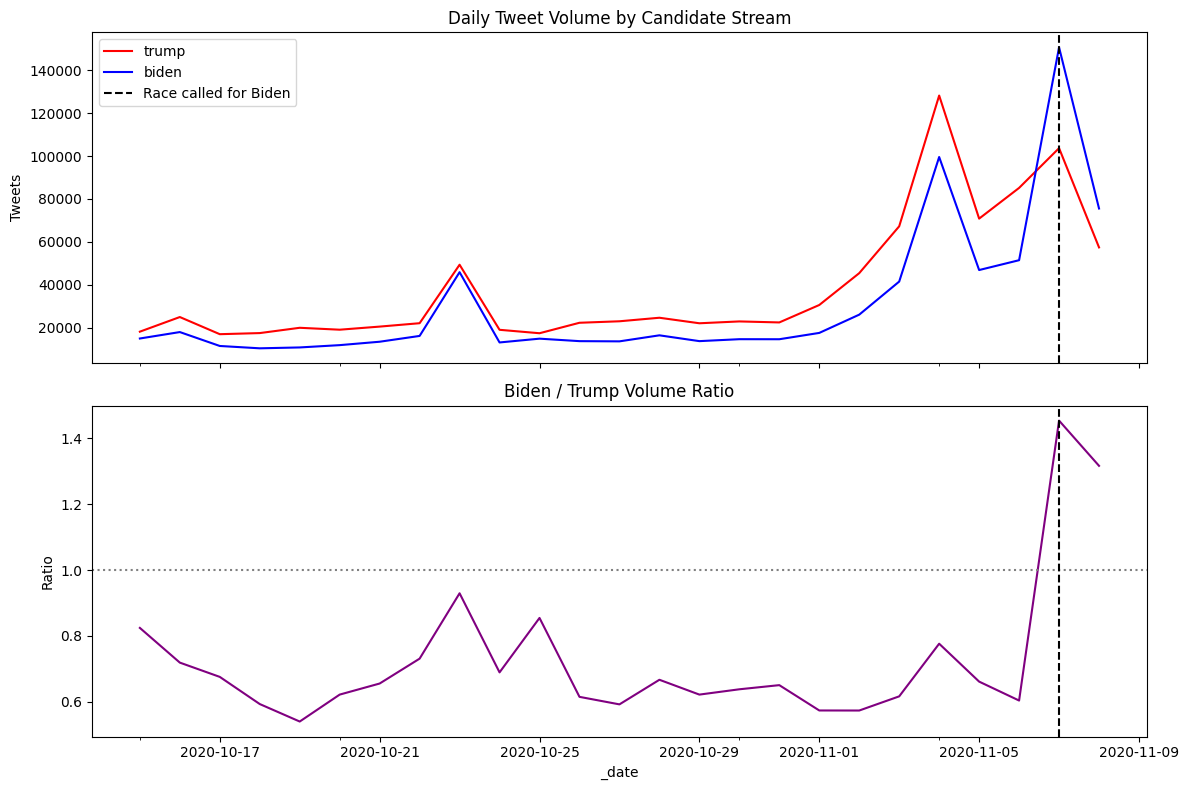

In [3]:

df_p1["candidate"] = ["trump"] * len(df_t) + ["biden"] * len(df_b)
df_p1["_date"] = pd.to_datetime(df_p1["date"]).dt.date
vol = df_p1.groupby(["_date", "candidate"]).size().unstack().fillna(0)
vol["b_t_ratio"] = vol["biden"] / vol["trump"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

vol[["trump", "biden"]].plot(ax=ax1, color=["red", "blue"])
ax1.set_title("Daily Tweet Volume by Candidate Stream")
ax1.set_ylabel("Tweets")
ax1.axvline(pd.to_datetime("2020-11-07"), color='black', linestyle='--', label="Race called for Biden")
ax1.legend()

vol["b_t_ratio"].plot(ax=ax2, color="purple")
ax2.axhline(1.0, color='gray', linestyle=':')
ax2.axvline(pd.to_datetime("2020-11-07"), color='black', linestyle='--')
ax2.set_title("Biden / Trump Volume Ratio")
ax2.set_ylabel("Ratio")

plt.tight_layout()
plt.show()


## N3: Cross-stream Assignment Bias Correction
The v2 pipeline handed 176,260 of 176,302 surviving dual-hashtag tweets to the Trump stream simply because of row order. This artifact is corrected in v3, cleanly splitting the streams into `trump_only`, `biden_only`, and `both`.

stream_membership
trump_only    622322
biden_only    491496
both          183935
Name: count, dtype: int64


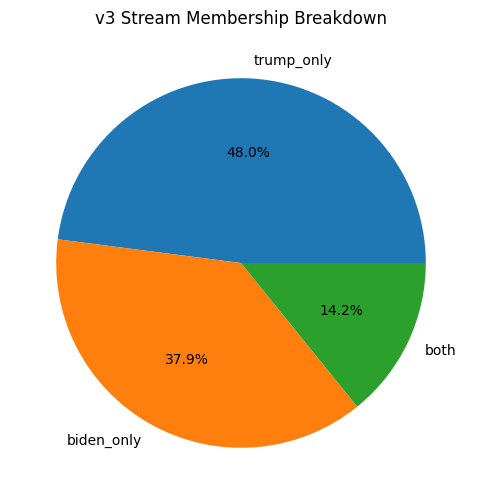

In [4]:

df_v3 = pd.read_parquet(ROOT / "data/02_interim/phase3_v3/twitter_sentiment_v3.parquet", columns=["stream_membership"])
counts = df_v3["stream_membership"].value_counts()
print(counts)
counts.plot.pie(autopct="%1.1f%%", figsize=(6,6), title="v3 Stream Membership Breakdown")
plt.ylabel("")
plt.show()


## N4: VADER Threshold Sensitivity
The ±0.05 compound score threshold is the standard from Hutto & Gilbert (2014), *"VADER: A Parsimonious Rule-based Model for Sentiment Analysis of Social Media Text"* (ICWSM-14), and is the documented convention in the official `vaderSentiment` README and NLTK's implementation.

Note: The large ~37% neutral mass is a lexicon *coverage* limit (VADER often scoring 0.0 when it recognizes no polarized words), not a finding that 37% of political tweets are neutral. See WP2 RoBERTa distributions for resolution of these tweets.

,Threshold,Positive %,Neutral %,Negative %
0,0.00,34.662066,38.681012,26.656922
1,0.05,34.252897,39.449880,26.297223
2,0.10,33.493199,40.857467,25.649334
3,0.20,31.890352,44.139910,23.969738


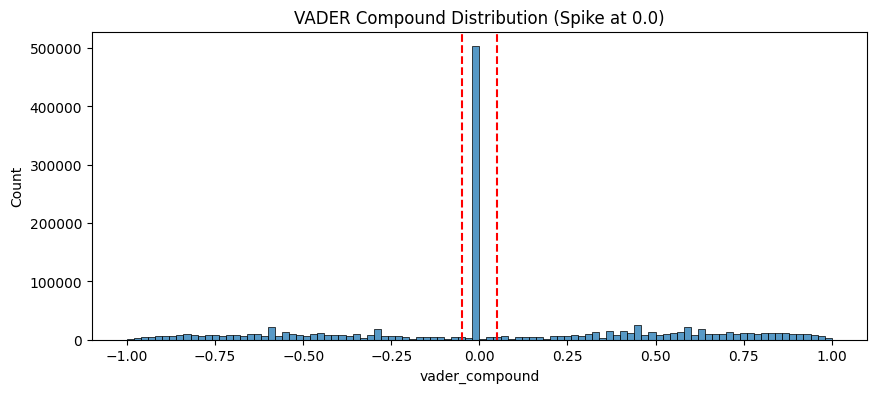

In [5]:

df_sent = pd.read_parquet(ROOT / "data/02_interim/phase3_v3/twitter_sentiment_v3.parquet", columns=["vader_compound"])
vader = df_sent["vader_compound"].dropna()

thresholds = [0.0, 0.05, 0.10, 0.20]
sens_data = []
for t in thresholds:
    pos = (vader > t).mean() * 100
    neg = (vader < -t).mean() * 100
    neu = (vader.between(-t, t)).mean() * 100
    sens_data.append({"Threshold": t, "Positive %": pos, "Neutral %": neu, "Negative %": neg})

sens_df = pd.DataFrame(sens_data)
display(sens_df)

plt.figure(figsize=(10, 4))
sns.histplot(vader, bins=100)
plt.axvline(0.05, color='red', linestyle='--')
plt.axvline(-0.05, color='red', linestyle='--')
plt.title("VADER Compound Distribution (Spike at 0.0)")
plt.show()


## N5: Primary Sentiment Model (RoBERTa)
Inference was natively executed on GPU for all rows using `cardiffnlp/twitter-roberta-base-sentiment-latest`.

In [6]:

print(f"Device Used: {p3.get('device_used')}")
print(f"Precision: {p3.get('precision')}")
print(f"Throughput: {p3.get('throughput_tweets_per_sec', 0):.2f} tweets/sec")
print(f"Wall clock seconds: {p3.get('wall_clock_seconds', 0):.2f}")

agree = load_json(ROOT / "output/results/phase3/v3/evidence/model_agreement.json")
if agree:
    print(f"\nCohen's Kappa (VADER vs RoBERTa): {agree.get('cohen_kappa')}")
    print(f"Pearson r: {agree.get('pearson_r')}")
    print("\nRoBERTa distribution for tweets where VADER scored 0.0:")
    print(json.dumps(agree.get('roberta_distribution_when_vader_zero'), indent=2))


Device Used: cuda
Precision: fp16
Throughput: 599.35 tweets/sec
Wall clock seconds: 2165.28

Cohen's Kappa (VADER vs RoBERTa): 0.3836344127380338
Pearson r: 0.4814403048263494

RoBERTa distribution for tweets where VADER scored 0.0:
{
  "neutral": 357950,
  "negative": 88348,
  "positive": 55686
}


## Daily Sentiment and Volume (Full v3 Window)
This is the full-window v3 series, distinct from N2's raw pre-filter hashtag-stream chart.

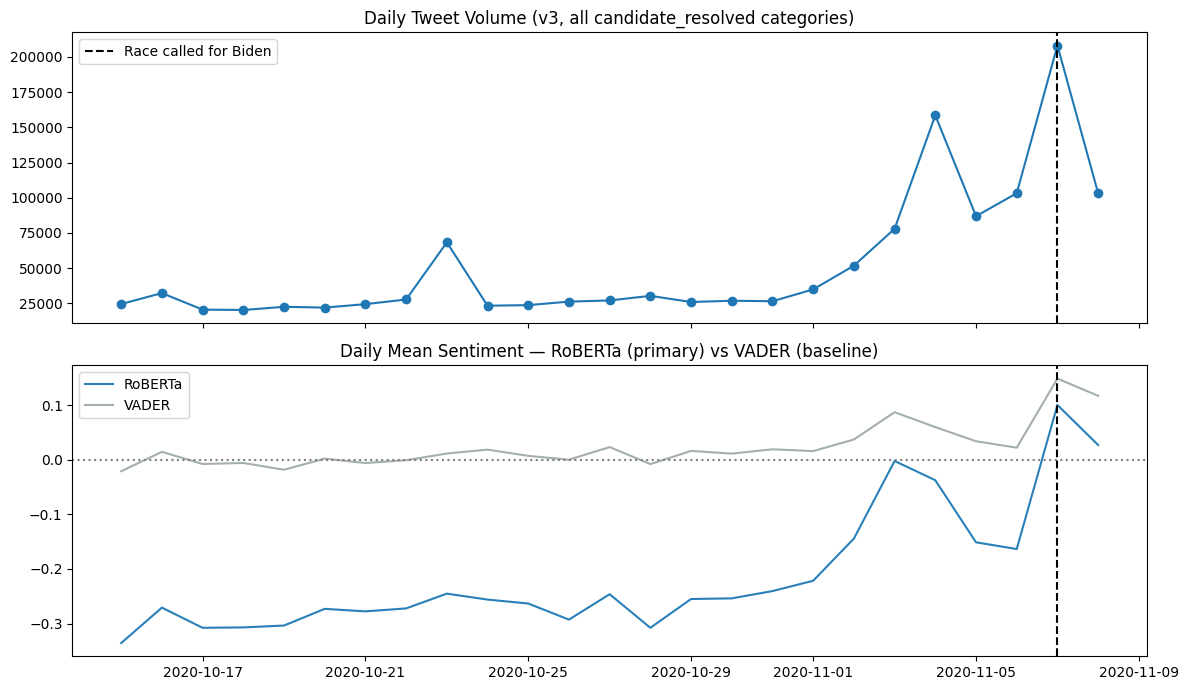

In [7]:

daily_v3 = pd.read_parquet(ROOT / "data/03_processed/v3/temporal_daily_matrix_v3.parquet")
daily_v3["timestamp_daily"] = pd.to_datetime(daily_v3["timestamp_daily"], utc=True)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(daily_v3["timestamp_daily"], daily_v3["volume"], marker="o")
axes[0].axvline(pd.Timestamp("2020-11-07", tz="UTC"), color="black", linestyle="--", label="Race called for Biden")
axes[0].set_title("Daily Tweet Volume (v3, all candidate_resolved categories)")
axes[0].legend()

axes[1].plot(daily_v3["timestamp_daily"], daily_v3["mean_sentiment_roberta"], color="#2980B9", label="RoBERTa")
axes[1].plot(daily_v3["timestamp_daily"], daily_v3["mean_sentiment_vader"], color="#7F8C8D", alpha=0.7, label="VADER")
axes[1].axhline(0, color="gray", linestyle=":")
axes[1].axvline(pd.Timestamp("2020-11-07", tz="UTC"), color="black", linestyle="--")
axes[1].set_title("Daily Mean Sentiment — RoBERTa (primary) vs VADER (baseline)")
axes[1].legend()
plt.tight_layout()
plt.show()


## N6: Language Survey
The v2 pipeline asserted Spanish as the target language by filtering via regex (which incorrectly flagged French and other languages as Spanish), artificially rendering "Other" unreachable. The v3 pipeline uses FastText lid.176 for a genuine distribution.

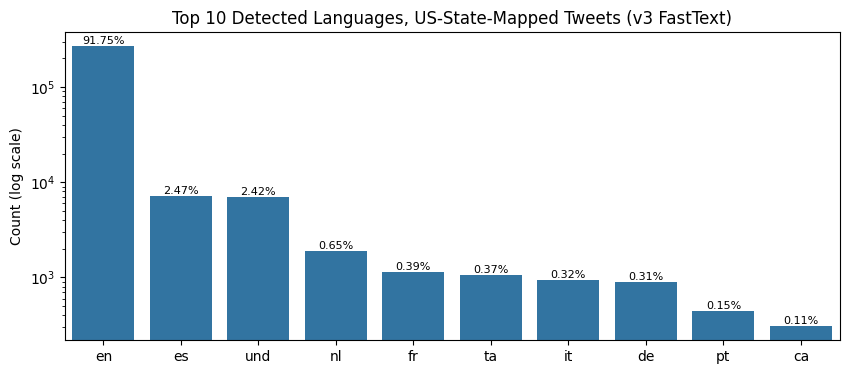

Languages clearing 1.0% of US-mapped tweets: ['es', 'und']


In [8]:

lang = load_json(ROOT / "output/results/phase2/v3/evidence/language_survey.json")
dist = lang.get("us_state_mapped", [])
if dist:
    top = dist[:10]
    names = [d["lang"] for d in top]
    counts = [d["n"] for d in top]

    plt.figure(figsize=(10, 4))
    sns.barplot(x=names, y=counts)
    plt.title("Top 10 Detected Languages, US-State-Mapped Tweets (v3 FastText)")
    plt.yscale("log")
    plt.ylabel("Count (log scale)")
    for i, d in enumerate(top):
        plt.text(i, d["n"], f"{d['pct']:.2f}%", ha="center", va="bottom", fontsize=8)
    plt.show()

    above = lang.get("languages_above_threshold_us", [])
    print(f"Languages clearing {lang.get('threshold_pct_for_dedicated_handling')}% of US-mapped tweets: {above}")


## N7: Geography Ceiling and Representativeness
H2 is a geocoded-subset analysis with a ~23% ceiling that no amount of parsing will lift. This is a structural limitation of Twitter data.

In [9]:

geo_report = load_json(ROOT / "output/results/phase4/v3/evidence/representativeness.json")

print(f"Correlation between state geocoded tweet share and actual certified 2020 vote share: {geo_report.get('correlation_geo_vs_votes')}")
print(f"Mean RoBERTa geocoded: {geo_report.get('mean_roberta_geocoded')}")
print(f"Mean RoBERTa non-geocoded: {geo_report.get('mean_roberta_non_geocoded')}")
print(geo_report.get('geocoding_bias_assessment'))


Correlation between state geocoded tweet share and actual certified 2020 vote share: 0.9113833259617181
Mean RoBERTa geocoded: -0.16853844132287352
Mean RoBERTa non-geocoded: -0.10698248278257398
If means differ materially, geocoding is not missing-at-random.


## N8: Inferential Models (H1 & H2)

In [10]:

h2_primary = p5.get("H2_spatial_primary", {})

for score in ["roberta", "vader"]:
    print(f"\n=== H2 Spatial ({score}) ===")
    for bg in ["national", "battleground", "safe"]:
        data = h2_primary.get(score, {}).get(bg, {})
        status = data.get("status")
        if status != "success":
            print(f"{bg.capitalize()}: {status} (N={data.get('N')})")
        else:
            print(f"{bg.capitalize()}: Beta_1 = {data.get('beta_1'):.3f}, p = {data.get('p_value'):.3f}, N = {data.get('N')}")

print("\n=== H1 Temporal (Bonferroni Adjusted) ===")
h1 = p5.get("H1_temporal", {}).get("roberta", {})
for event, ev_data in h1.items():
    print(f"Event: {event}")
    print(f"  Raw p: {ev_data.get('raw_p_value'):.2e}")
    print(f"  Adj p (alpha=0.0125): {ev_data.get('bonferroni_adj_p_value'):.2e} (Significant: {ev_data.get('significant_at_adj_alpha_0.0125')})")



=== H2 Spatial (roberta) ===
National: Beta_1 = 29.393, p = 0.109, N = 51
Battleground: Beta_1 = -6.238, p = 0.738, N = 10
Safe: Beta_1 = 21.716, p = 0.277, N = 41

=== H2 Spatial (vader) ===
National: Beta_1 = 113.716, p = 0.002, N = 51
Battleground: Beta_1 = 53.727, p = 0.251, N = 10
Safe: Beta_1 = 96.732, p = 0.018, N = 41

=== H1 Temporal (Bonferroni Adjusted) ===
Event: 2020 presidential election day
  Raw p: 6.69e-29
  Adj p (alpha=0.0125): 2.68e-28 (Significant: True)
Event: AP projects Joe Biden as president-elect
  Raw p: 9.52e-09
  Adj p (alpha=0.0125): 3.81e-08 (Significant: True)
Event: Dueling presidential town halls
  Raw p: 5.92e-03
  Adj p (alpha=0.0125): 2.37e-02 (Significant: True)
Event: Final presidential debate
  Raw p: 3.09e-01
  Adj p (alpha=0.0125): 1.00e+00 (Significant: False)


## N9: Project Limitations

| # | Limitation | Status after remediation |
|---|---|---|
| 1 | RoBERTa deferred | **Resolved** — real GPU inference, [sentiment_manifest_v3.json](../../output/results/phase3/v3/sentiment_manifest_v3.json) |
| 2 | Dual-hashtag tweets misassigned to Trump | **Resolved** — `both` category, [preprocessing_manifest_v3.json](../../output/results/phase2/v3/preprocessing_manifest_v3.json) |
| 3 | Dedup deleted distinct users' identical short texts | **Resolved** — key now `(user_id, text)`, [preprocessing_manifest_v3.json](../../output/results/phase2/v3/preprocessing_manifest_v3.json) |
| 4 | Language detector could not emit "Other" | **Resolved** — fasttext lid.176, [language_survey.json](../../output/results/phase2/v3/evidence/language_survey.json) |
| 5 | US geocoding ceiling ~22.6% | **Structural** — quantified, not fixable, [representativeness.json](../../output/results/phase4/v3/evidence/representativeness.json) |
| 6 | `candidate` = hashtag stream ≠ political stance | **Structural** — inherent to the source |
| 7 | Nov 9–15 unobserved; post-call spike decay unmeasured | **Structural** — Kaggle collection boundary |
| 8 | 4 events, hourly data → limited ITSA power | **Structural** — Bonferroni-adjusted |
| 9 | Silver labels are LLM-generated, anchored on only 15 human seeds | **Structural** — report agreement, WP3 |
